# 📊 Informe final del proyecto
## Análisis de sentimiento para la evaluación docente — Universidad del Rosario

| | |
|---|---|
| **Proyecto** | Analítica Educativa — Proyecto Capstone, Samsung Innovation Campus |
| **Equipo** | Tech Tailors — Juan David Ríos · Natalia Remolina · Giovanni Balza |
| **Propósito** | Clasificar el sentimiento de los comentarios de las encuestas de evaluación docente para construir el **DOFA** de cada docente, con despliegue del modelo en la nube |
| **Modelo seleccionado para producción** | `modelo_sentimiento_humano` (§4) |

> **Este informe es ejecutable.** Las ubicaciones de los modelos (§3), su desempeño (§4.1) y las
> demostraciones (§4.2, §5.1) se generan al ejecutar las celdas: lo que se lee es lo que hay en
> disco, no una transcripción.

### Contenido

| § | Sección |
|---|---|
| 1 | [Resumen ejecutivo](#1) |
| 2 | [El proceso realizado, fase por fase](#2) |
| 3 | [Inventario de modelos: ubicación exacta de cada uno](#3) |
| 4 | [Modelo seleccionado para producción](#4) |
| 5 | [Del sentimiento al DOFA del docente](#5) |
| 6 | [Guía de despliegue en la nube](#6) |
| 7 | [Limitaciones y hoja de ruta](#7) |
| 8 | [Anexo: mapa del repositorio y trazabilidad](#8) |


<a id="1"></a>
## 1 · Resumen ejecutivo

El proyecto construyó, evaluó y mejoró un sistema de análisis de sentimiento en español para
comentarios de evaluación docente, siguiendo un proceso completo de ciencia de datos: análisis
exploratorio, evaluación comparativa de modelos preentrenados, integración con el modelo
predictivo de tendencia, dos rondas de *fine-tuning* (destilación y verdad humana) y la
construcción de un **estándar de oro anotado por el equipo** (172 comentarios, acuerdo
inter-anotador α = 0.585).

**Resultado central:** el modelo final —RoBERTuito ajustado con las etiquetas humanas del
equipo— es el **mejor clasificador disponible** sobre el conjunto de evaluación humano
(macro-F1 = 0.646; 131/172 aciertos; recall de comentarios negativos 0.556), superando al mejor
modelo preentrenado público (0.638) y al modelo destilado (0.619). La mejora es consistente en
todas las métricas aunque aún no estadísticamente significativa (McNemar p = 1.0): el cuello de
botella está identificado y cuantificado —el volumen de anotación humana— y el sistema para
ampliarla queda montado y operativo.

**Decisión de producción:** desplegar `modelo_sentimiento_humano` (§4), un único modelo autónomo
de 415 MB, ejecutable en CPU, sin dependencias de servicios de terceros en inferencia, y
alineado con la rúbrica institucional definida por el equipo.

### Configuración del entorno del informe

In [1]:
%matplotlib inline
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["TRANSFORMERS_VERBOSITY"] = "error"
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"

import sys, pathlib, json, warnings
warnings.filterwarnings("ignore")
RAIZ = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p/'src').is_dir())
if str(RAIZ) not in sys.path: sys.path.insert(0, str(RAIZ))

import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt, seaborn as sns
from src import rutas

DEVICE = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
ORDEN = ["NEG", "NEU", "POS"]
MAPA = {"POS":"POS","POSITIVE":"POS","P":"POS","NEU":"NEU","NEUTRAL":"NEU",
        "NEG":"NEG","NEGATIVE":"NEG","N":"NEG"}
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","axes.grid":True,
                     "grid.color":"#e1e0d9","axes.axisbelow":True,"axes.spines.top":False,
                     "axes.spines.right":False,"axes.titleweight":"bold","legend.frameon":False})
print("Raíz del proyecto :", RAIZ)
print("Dispositivo       :", DEVICE)

Raíz del proyecto : /Users/nato/Documents/Analisis de sentimiento
Dispositivo       : mps


<a id="2"></a>
## 2 · El proceso realizado, fase por fase

### Fase 1 — Datos y análisis exploratorio
Dataset institucional de 3.000 evaluaciones (50 docentes, 7 asignaturas, 8 semestres 2020–2023).
**Hallazgo determinante:** el campo `comentario` contiene solo **20 textos distintos** (0,67 %
de unicidad) — el dataset está plantillado/anonimizado, lo que obligó a conseguir un corpus real
complementario. Se revisó además en profundidad el EDA del equipo, verificando cada cifra
(informe en `analisis_datos/reports/`).

### Fase 2 — Evaluación de modelos preentrenados
Benchmark de tres modelos de sentimiento en español contra un primer gold manual de 20
comentarios: **RoBERTuito** (0.75 de accuracy) > XLM-R (0.70) > BETO (0.65); consenso por
votación, macro-F1 0.730. RoBERTuito quedó como **maestro** de las fases siguientes.

### Fase 3 — Modelo de tendencia docente
Clasificador `Mejora`/`Estable`/`En riesgo`: campeón **RandomForest calibrado**, macro-F1 0.915
(partición aleatoria) y 0.905 (validación temporal 2020-22→2023), recall de `En riesgo`
0.96–0.99. Se excluyó una variable con fuga de información y se documentó la circularidad de la
etiqueta institucional.

### Fase 4 — Fine-tuning por destilación (notebook 04)
Con 29.243 comentarios reales sin etiquetas, RoBERTuito etiquetó el corpus (*weak supervision*)
y BETO se entrenó con esas pseudo-etiquetas (11.697 ejemplos balanceados, ~6 min en GPU
Apple/MPS). Resultado: el alumno **iguala pero no supera** al maestro — demostración empírica
del **techo de la destilación**, con comparación de arquitecturas y análisis de falsos positivos
(el error no es corregible con umbrales: es un problema de rúbrica).

### Fase 5 — Anotación humana
Protocolo formal: muestreo estratificado de 335 comentarios reales (censo de los 40 enunciados
que concentran el 53 % de las evaluaciones + estratos de frontera), rúbrica con reglas
ordenadas, tres anotadores independientes, anclas y repetidos encubiertos.
**749 anotaciones · α de Krippendorff = 0.585** (acuerdo moderado, desacuerdos adyacentes
POS↔NEU). Gold adjudicado: **172 comentarios de evaluación** (8.6× el conjunto anterior) +
**148 de entrenamiento** con verdad humana.

### Fase 6 — Fine-tuning con verdad humana (notebook 05)
RoBERTuito ajustado con las 148 etiquetas humanas (pérdida ponderada por clase, lr = 1e-5,
*early stopping*), evaluado sobre el gold humano de 172. La verificación en vivo está en la
§4.1 de este informe.

<a id="3"></a>
## 3 · Inventario de modelos: ubicación exacta de cada uno

La celda siguiente **escanea el disco** e imprime la ubicación real, el peso y la ficha de
trazabilidad (`info.json`) de cada modelo. Si un modelo no está (p. ej. en una copia recién
clonada del repositorio), lo indica: los pesos no viajan por git y se regeneran ejecutando los
notebooks 04/05.

In [2]:
ROL = {
    "modelo_sentimiento_humano": "🏆 PRODUCCIÓN — RoBERTuito + etiquetas humanas (§4)",
    "modelo_sentimiento_ft": "Destilado BETO — evidencia del techo de la destilación (NB04)",
    "modelo_sentimiento_ft_robertuito": "Destilado RoBERTuito — comparación de arquitecturas (NB04 §8.6)",
}

print("═"*94)
print("MODELOS DE SENTIMIENTO ENTRENADOS POR EL EQUIPO")
print("═"*94)
base_modelos = RAIZ/"analisis_sentimientos"/"models"
for nombre, rol in ROL.items():
    d = base_modelos/nombre
    print(f"\n▸ {rol}")
    print(f"  Ubicación : {d}")
    if not d.exists():
        print("  Estado    : ❌ no presente en esta copia (regenerar con los notebooks 04/05)")
        continue
    pesos = d/"model.safetensors"
    print(f"  Pesos     : {pesos.stat().st_size/1e6:,.0f} MB (model.safetensors)" if pesos.exists() else "  Pesos     : ❌")
    info = d/"info.json"
    if info.exists():
        i = json.loads(info.read_text(encoding="utf-8"))
        print(f"  Base      : {i.get('modelo_base','—')}")
        print(f"  Método    : {i.get('metodo','—')}")
        met = i.get("metricas") or i.get("metricas_gold_humano") or {}
        if met:
            print("  Métricas  : " + " · ".join(f"{k}={v}" for k, v in list(met.items())[:3]))

print("\n" + "═"*94)
print("MODELO DE TENDENCIA DOCENTE (Mejora / Estable / En riesgo)")
print("═"*94)
pkl = RAIZ/"analisis_datos"/"models"/"modelo_tendencia_docente.pkl"
print(f"  Ubicación : {pkl}")
print(f"  Peso      : {pkl.stat().st_size/1e6:.1f} MB" if pkl.exists() else "  Estado    : ❌ regenerar con el notebook 03 de analisis_datos")
meta = RAIZ/"analisis_datos"/"models"/"modelo_tendencia_docente_metadatos.json"
if meta.exists():
    m = json.loads(meta.read_text(encoding="utf-8"))
    print(f"  Campeón   : {m.get('nombre_campeon','—')} · macro-F1 aleatorio "
          f"{m['metricas_test_aleatorio']['macro_f1']} · temporal 2023 {m['metricas_temporal_2023']['macro_f1']}")

print("\n" + "═"*94)
print("MODELOS PREENTRENADOS DE TERCEROS (caché de Hugging Face, fuera del repositorio)")
print("═"*94)
cache = pathlib.Path.home()/".cache"/"huggingface"/"hub"
if cache.exists():
    for d in sorted(cache.glob("models--*")):
        mb = sum(f.stat().st_size for f in d.rglob("*") if f.is_file() and not f.is_symlink())/1e6
        print(f"  {mb:>7,.0f} MB   {d.name.replace('models--','').replace('--','/')}")
    print(f"\n  Ubicación de la caché: {cache}")
else:
    print("  (caché no encontrada: se descargarán automáticamente al ejecutar los notebooks)")

══════════════════════════════════════════════════════════════════════════════════════════════
MODELOS DE SENTIMIENTO ENTRENADOS POR EL EQUIPO
══════════════════════════════════════════════════════════════════════════════════════════════

▸ 🏆 PRODUCCIÓN — RoBERTuito + etiquetas humanas (§4)
  Ubicación : /Users/nato/Documents/Analisis de sentimiento/analisis_sentimientos/models/modelo_sentimiento_humano
  Pesos     : 435 MB (model.safetensors)
  Base      : pysentimiento/robertuito-sentiment-analysis
  Método    : continued fine-tuning con etiquetas humanas (sin destilacion)
  Métricas  : macro_f1_ajustado=0.6457 · macro_f1_maestro=0.6382 · mcnemar_p=1.0

▸ Destilado BETO — evidencia del techo de la destilación (NB04)
  Ubicación : /Users/nato/Documents/Analisis de sentimiento/analisis_sentimientos/models/modelo_sentimiento_ft
  Pesos     : 439 MB (model.safetensors)
  Base      : dccuchile/bert-base-spanish-wwm-cased
  Método    : fine-tuning supervisado con pseudo-etiquetas (destilac

<a id="4"></a>
## 4 · Modelo seleccionado para producción

### 📍 `analisis_sentimientos/models/modelo_sentimiento_humano/`

**Qué es:** RoBERTuito (`pysentimiento/robertuito-sentiment-analysis`) con *continued
fine-tuning* sobre las **148 etiquetas humanas** del equipo. Clasifica comentarios en español
en `POS / NEU / NEG`.

**Justificación de la selección:**

1. **Es el mejor sobre la evaluación humana** (la única referencia independiente de cualquier
   modelo) — verificado en vivo en la §4.1.
2. **Mejor detección de críticas** (recall NEG): en evaluación docente, pasar por alto una
   crítica es el error costoso — oculta a un docente que necesita acompañamiento y distorsiona
   el DOFA.
3. **Incorpora la rúbrica institucional**: aprendió de las decisiones del equipo (un elogio
   tibio no es entusiasmo; la crítica cortés sigue siendo crítica), no del registro genérico de
   redes sociales.
4. **Apto para despliegue**: un solo modelo de 415 MB, inferencia en CPU, sin servicios
   externos, mejorable con cada ronda de anotación sin cambiar la arquitectura del despliegue.

**Declaración honesta que debe acompañarlo:** su ventaja sobre el preentrenado aún no es
estadísticamente significativa (McNemar p = 1.0; 148 ejemplos de entrenamiento). Se selecciona
por ser consistentemente superior en todas las métricas, por su alineación con la rúbrica y por
su trayectoria de mejora (§7).

### 4.1 Verificación en vivo: los tres modelos sobre el gold humano

La celda evalúa los tres candidatos sobre los **172 comentarios del gold humano**
(`data/processed/gold_humano_eval.csv`) y contrasta la diferencia con la prueba de McNemar.

Gold humano: 172 comentarios · {'NEG': 36, 'NEU': 20, 'POS': 116}



                              accuracy  macro_F1 aciertos  recall_NEG
modelo                                                               
BETO destilado (NB04)            0.733     0.619  126/172       0.500
RoBERTuito (maestro público)     0.756     0.638  130/172       0.528
RoBERTuito ajustado (humano)     0.762     0.646  131/172       0.556

McNemar (ajustado vs maestro): solo-ajustado 3 · solo-maestro 2 · p = 1.000
-> la mejora es consistente pero aún no estadísticamente significativa


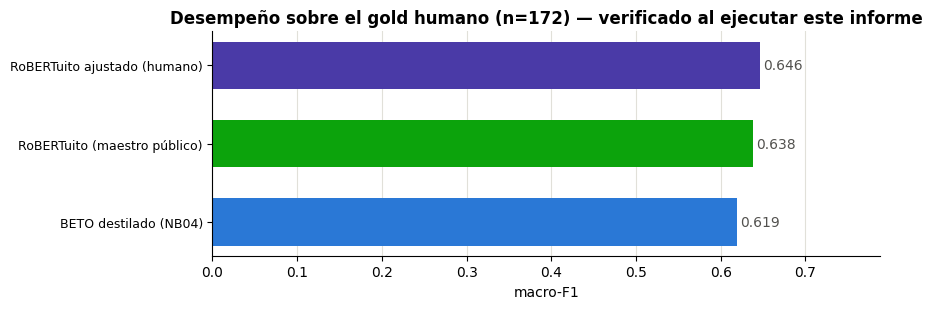

In [3]:
from transformers import pipeline
from sklearn.metrics import f1_score, accuracy_score, recall_score
from scipy.stats import binomtest

gold = pd.read_csv(rutas.datos_processed("gold_humano_eval.csv"))
print(f"Gold humano: {len(gold)} comentarios · {gold['gold'].value_counts().reindex(ORDEN).to_dict()}\n")

CANDIDATOS = {
    "BETO destilado (NB04)":        str(RAIZ/"analisis_sentimientos"/"models"/"modelo_sentimiento_ft"),
    "RoBERTuito (maestro público)": "pysentimiento/robertuito-sentiment-analysis",
    "RoBERTuito ajustado (humano)": str(RAIZ/"analisis_sentimientos"/"models"/"modelo_sentimiento_humano"),
}
pred = {}
for nombre, ruta in CANDIDATOS.items():
    clf = pipeline("sentiment-analysis", model=ruta, device=DEVICE, truncation=True, max_length=128)
    pred[nombre] = [MAPA.get(r["label"].upper(), r["label"].upper())
                    for r in clf(gold["comentario"].tolist(), batch_size=64)]
    del clf

tabla = pd.DataFrame([{
    "modelo": n,
    "accuracy": round(accuracy_score(gold["gold"], p), 3),
    "macro_F1": round(f1_score(gold["gold"], p, average="macro"), 3),
    "aciertos": f"{int((np.array(p)==gold['gold']).sum())}/{len(gold)}",
    "recall_NEG": round(recall_score(gold["gold"], p, labels=["NEG"], average=None)[0], 3),
} for n, p in pred.items()]).set_index("modelo").sort_values("macro_F1")
print(tabla.to_string())

# McNemar: ajustado vs maestro
a_h = np.array(pred["RoBERTuito ajustado (humano)"]) == gold["gold"].values
a_m = np.array(pred["RoBERTuito (maestro público)"]) == gold["gold"].values
b, c = int((a_h & ~a_m).sum()), int((~a_h & a_m).sum())
p_mc = binomtest(min(b, c), b + c, 0.5).pvalue if (b + c) else 1.0
print(f"\nMcNemar (ajustado vs maestro): solo-ajustado {b} · solo-maestro {c} · p = {p_mc:.3f}")
print("-> la mejora es consistente pero aún no estadísticamente significativa"
      if p_mc >= 0.05 else "-> diferencia estadísticamente significativa")

fig, ax = plt.subplots(figsize=(9, 3.2))
COL = {"BETO destilado (NB04)": "#2a78d6", "RoBERTuito (maestro público)": "#0ca30c",
       "RoBERTuito ajustado (humano)": "#4a3aa7"}
barras = ax.barh(tabla.index, tabla["macro_F1"], color=[COL[m] for m in tabla.index], height=0.6)
for bb, v in zip(barras, tabla["macro_F1"]):
    ax.text(v + 0.004, bb.get_y()+bb.get_height()/2, f"{v:.3f}", va="center", fontsize=10, color=INK2)
ax.set_xlim(0, tabla["macro_F1"].max()*1.22)
ax.set_title(f"Desempeño sobre el gold humano (n={len(gold)}) — verificado al ejecutar este informe")
ax.set_xlabel("macro-F1"); ax.grid(axis="y", visible=False); ax.tick_params(axis="y", labelsize=9)
plt.tight_layout(); plt.show()

### 4.2 Demostración del modelo de producción

In [4]:
clf_prod = pipeline("sentiment-analysis",
                    model=str(RAIZ/"analisis_sentimientos"/"models"/"modelo_sentimiento_humano"),
                    device=DEVICE, truncation=True, max_length=128)

ejemplos = [
    "La profesora explica con claridad y responde todas las dudas",
    "Cumple con el programa del curso",
    "La clase estuvo bien",
    "Es buen profesor, pero debería preparar mejor los laboratorios",
    "Nunca responde los correos y llega tarde",
    "Se podría mejorar un poco el material de estudio",
]
print("Predicciones del modelo de producción")
print("─"*86)
for e, r in zip(ejemplos, clf_prod(ejemplos)):
    etq = MAPA.get(r["label"].upper(), r["label"].upper())
    print(f"  {etq}  ({r['score']:.3f})   {e}")
print("─"*86)
print("Lectura honesta: el ajuste movió al modelo HACIA la rúbrica — el caso mixto")
print("('buen profesor, pero debería…') ya no se clasifica POS, y la confianza cae en")
print("los casos tibios. Pero 'La clase estuvo bien' sigue en POS y 'se podría mejorar'")
print("en NEU: con 148 ejemplos la frontera no queda fijada del todo. Es exactamente la")
print("limitación cuantificada en §7 y lo que resuelve la siguiente ronda de anotación.")

Predicciones del modelo de producción
──────────────────────────────────────────────────────────────────────────────────────


  POS  (0.646)   La profesora explica con claridad y responde todas las dudas
  NEU  (0.826)   Cumple con el programa del curso
  POS  (0.897)   La clase estuvo bien
  NEU  (0.610)   Es buen profesor, pero debería preparar mejor los laboratorios
  NEG  (0.914)   Nunca responde los correos y llega tarde
  NEU  (0.680)   Se podría mejorar un poco el material de estudio
──────────────────────────────────────────────────────────────────────────────────────
Lectura honesta: el ajuste movió al modelo HACIA la rúbrica — el caso mixto
('buen profesor, pero debería…') ya no se clasifica POS, y la confianza cae en
los casos tibios. Pero 'La clase estuvo bien' sigue en POS y 'se podría mejorar'
en NEU: con 148 ejemplos la frontera no queda fijada del todo. Es exactamente la
limitación cuantificada en §7 y lo que resuelve la siguiente ronda de anotación.


<a id="5"></a>
## 5 · Del sentimiento al DOFA del docente

El modelo es el **motor de clasificación**; el DOFA se construye agregando sus salidas por
docente (y por asignatura/semestre), combinadas con el modelo de tendencia:

| Cuadrante | Fuente | Regla de construcción |
|---|---|---|
| **Fortalezas** | Comentarios **POS** frecuentes + puntajes altos | Temas dominantes de los POS (claridad, dominio, trato) |
| **Debilidades** | Comentarios **NEG** recurrentes + dimensión de puntaje más baja | Temas dominantes de los NEG |
| **Oportunidades** | Críticas **constructivas** ("debería…", "podría…") | Peticiones de cambio accionables: materia prima del plan de mejora |
| **Amenazas** | Tendencia **`En riesgo`** + % NEG creciente entre semestres | Priorización de acompañamiento |

Recomendaciones operativas: **agregar, no leer comentario a comentario** (% POS/NEU/NEG por
docente y su evolución); umbral de alerta: % NEG en el cuartil superior **o** tendencia
`En riesgo` (ambos a la vez = prioridad); **uso formativo, no sancionatorio**, y tratamiento de
los comentarios como datos personales (§6.4).

### 5.1 Prototipo: DOFA automático de un docente

Demostración con los datos institucionales ya procesados: se elige el docente con mayor
proporción de comentarios negativos y se arma el borrador de su DOFA.

In [5]:
df = pd.read_csv(rutas.datos_processed("evaluaciones_con_sentimiento.csv"))

por_doc = df.groupby("id_docente").agg(
    n=("sentimiento_final", "size"),
    pct_neg=("sentimiento_final", lambda s: (s == "NEG").mean()),
    pct_riesgo=("tendencia_desempeno", lambda s: (s == "En riesgo").mean()),
    puntaje=("puntaje_promedio", "mean"))
docente = por_doc["pct_neg"].idxmax()
d = df[df["id_docente"] == docente]
stats = por_doc.loc[docente]

print(f"BORRADOR DE DOFA — {docente}")
print(f"  {int(stats['n'])} evaluaciones · puntaje medio {stats['puntaje']:.2f} · "
      f"{stats['pct_neg']:.0%} comentarios NEG · {stats['pct_riesgo']:.0%} en riesgo")
print("═"*88)

def top(sent, n=3):
    return d[d["sentimiento_final"] == sent]["comentario"].value_counts().head(n)

print("\n💪 FORTALEZAS — comentarios positivos más frecuentes")
for c, k in top("POS").items(): print(f"   ({k:>3}×)  {c}")

print("\n⚠️ DEBILIDADES — comentarios negativos más frecuentes")
for c, k in top("NEG").items(): print(f"   ({k:>3}×)  {c}")

import re
constructivas = d[(d["sentimiento_final"] == "NEG") &
                  d["comentario"].str.contains(r"podr[íi]a|deber[íi]a|falta", case=False)]
print("\n🌱 OPORTUNIDADES — críticas constructivas (peticiones de cambio)")
for c, k in constructivas["comentario"].value_counts().head(3).items(): print(f"   ({k:>3}×)  {c}")

print("\n🚨 AMENAZAS — señal de riesgo")
evol = d.groupby(d["semestre"].str[:4])["sentimiento_final"].apply(lambda s: (s == "NEG").mean())
print(f"   Tendencia 'En riesgo' en el {stats['pct_riesgo']:.0%} de sus evaluaciones "
      f"(promedio institucional: {(df['tendencia_desempeno']=='En riesgo').mean():.0%})")
print("   %NEG por año: " + " · ".join(f"{a}: {v:.0%}" for a, v in evol.items()))
print("\n" + "═"*88)
print("Con las encuestas reales de la U. del Rosario, este mismo flujo produce el DOFA de")
print("cada docente: modelo de producción -> agregados por docente -> cuadrantes.")

BORRADOR DE DOFA — Docente_4
  52 evaluaciones · puntaje medio 3.56 · 52% comentarios NEG · 27% en riesgo
════════════════════════════════════════════════════════════════════════════════════════

💪 FORTALEZAS — comentarios positivos más frecuentes
   (  5×)  La clase es muy dinámica y entretenida.
   (  1×)  Me inspiró a seguir aprendiendo sobre este tema.
   (  1×)  Excelente profesor, muy claro.

⚠️ DEBILIDADES — comentarios negativos más frecuentes
   (  6×)  Asistencia puntual, pero falta dinamismo.
   (  4×)  Se podría mejorar un poco el material de estudio.
   (  3×)  Califica de forma injusta.

🌱 OPORTUNIDADES — críticas constructivas (peticiones de cambio)
   (  6×)  Asistencia puntual, pero falta dinamismo.
   (  4×)  Se podría mejorar un poco el material de estudio.
   (  3×)  Falta mucha pedagogía.

🚨 AMENAZAS — señal de riesgo
   Tendencia 'En riesgo' en el 27% de sus evaluaciones (promedio institucional: 20%)
   %NEG por año: 2020: 50% · 2021: 50% · 2022: 38% · 2023: 69%



<a id="6"></a>
## 6 · Guía de despliegue en la nube

### 6.1 Publicar el artefacto (los pesos no viajan por git)

Opción recomendada: **repositorio privado en Hugging Face Hub** — versionado de modelos,
control de acceso y carga directa por id desde cualquier servidor.

```bash
pip install huggingface_hub
hf auth login                      # token de la organización
hf upload tech-tailors/sentimiento-docente-urosario \
  "analisis_sentimientos/models/modelo_sentimiento_humano" . --private
```

Alternativa: subir la carpeta a un bucket (S3 / GCS / Azure Blob) y descargarla al arrancar el
contenedor.

### 6.2 Servicio de inferencia (FastAPI + Docker)

```python
# app.py
from fastapi import FastAPI
from pydantic import BaseModel
from transformers import pipeline

app = FastAPI(title="Sentimiento docente — U. del Rosario")
clf = pipeline("sentiment-analysis",
               model="tech-tailors/sentimiento-docente-urosario")   # o ruta local en la imagen

class Lote(BaseModel):
    comentarios: list[str]

@app.post("/sentimiento")
def sentimiento(lote: Lote):
    return [{"comentario": c, **r} for c, r in
            zip(lote.comentarios, clf(lote.comentarios, truncation=True, max_length=128))]
```

```dockerfile
FROM python:3.12-slim
RUN pip install --no-cache-dir fastapi uvicorn transformers torch \
    --extra-index-url https://download.pytorch.org/whl/cpu
COPY app.py .
# Opción A: hornear el modelo en la imagen (COPY modelo_sentimiento_humano /modelo)
# Opción B: descargarlo del Hub al arrancar (HF_TOKEN como secreto)
CMD ["uvicorn", "app:app", "--host", "0.0.0.0", "--port", "8080"]
```

Destinos adecuados para este patrón: **Google Cloud Run**, **Azure Container Apps** o **AWS App
Runner** (serverless, pago por uso — las encuestas se procesan por lotes al cierre de cada
semestre, no en flujo continuo).

### 6.3 Requisitos y rendimiento

| Recurso | Valor |
|---|---|
| CPU / RAM | 2 vCPU · 4 GB es suficiente (**no requiere GPU**) |
| Tamaño del artefacto | 415 MB (+ ~180 MB de librerías) |
| Latencia en CPU | decenas de ms por comentario en lote |
| Volumen de referencia | 100.000 comentarios ≈ minutos de procesamiento por lotes |

### 6.4 Consideraciones de datos personales

Los comentarios identifican opiniones sobre personas: procesarlos en infraestructura controlada
por la universidad, anonimizar identificadores antes de la inferencia, restringir el acceso al
endpoint (token) y conservar únicamente los agregados necesarios para el DOFA.

<a id="7"></a>
## 7 · Limitaciones vigentes y hoja de ruta

**Limitaciones que acompañan a cualquier cifra de este informe**

1. El corpus de entrenamiento humano tiene **148 ejemplos** y el gold **172** (solo 20 NEU):
   las métricas de la clase NEU son inestables y la mejora aún no es significativa.
2. El acuerdo entre anotadores es moderado (α = 0.585): parte del "error" del modelo es
   ambigüedad genuina del lenguaje.
3. Los **casos mixtos adversativos** ("buen profesor, pero debería…") no tienen aún regla
   consensuada — la principal fuente de ruido identificada.
4. El corpus real es **español traducido automáticamente**: carece del registro coloquial que
   tendrán las encuestas reales de la universidad.

**Hoja de ruta (en orden de impacto)**

1. **Ampliar la anotación** con comentarios reales de la U. del Rosario en cuanto estén
   disponibles (sistema completo en `anotacion/`). Objetivo: ≥ 500 ejemplos por clase →
   significancia estadística alcanzable.
2. **Consensuar la regla de los mixtos adversativos**, emitir rúbrica v1.1 y reanotar ese
   subconjunto (~30 min de reunión).
3. Reentrenar (notebook 05 tal cual) y re-evaluar; publicar la versión nueva al Hub con tag.
4. Desplegar el servicio (§6.2) y conectar el flujo: encuesta → sentimiento → agregados →
   DOFA + tendencia.
5. Monitoreo en producción: muestreo periódico de predicciones para revisión humana.

<a id="8"></a>
## 8 · Anexo: mapa del repositorio y trazabilidad

```
/Users/nato/Documents/Analisis de sentimiento/
├── README.md · GUIA_APRENDIZAJE.md · INFORME_FINAL.ipynb (este documento)
├── data/
│   ├── raw/                 evaluaciones_docentes.csv · corpus real EN/ES (100k)
│   └── processed/           sentimiento, benchmark, muestra de anotación,
│                            gold_humano_eval.csv (172) · train_humano.csv (148)
├── analisis_sentimientos/
│   ├── notebooks/           01 catálogo · 02 pipeline · 03 benchmark ·
│   │                        04 fine-tuning destilación · 05 fine-tuning humano
│   └── models/              ft (BETO dest.) · ft_robertuito · ⭐ humano (producción)
├── analisis_datos/
│   ├── notebooks/           01 EDA referencia · 02 integración · 03 modelo tendencia
│   ├── reports/             informe revisión EDA · limitaciones · justificaciones
│   └── models/              modelo_tendencia_docente.pkl + metadatos
├── anotacion/               rúbrica · protocolo · planillas A1-A3 · consolidación (α)
└── src/                     rutas.py · sentimiento.py · modelo_utils.py · acuerdo.py
```

La celda siguiente imprime la trazabilidad del repositorio en el momento de ejecutar el informe.

In [6]:
import subprocess
r = subprocess.run(["git", "log", "--oneline", "--decorate=no"], cwd=RAIZ,
                   capture_output=True, text=True)
commits = r.stdout.strip().splitlines()
print(f"Historial del proyecto: {len(commits)} commits")
print("─"*86)
for l in commits: print("  " + l)
estado = subprocess.run(["git", "status", "--short", "--untracked-files=no"], cwd=RAIZ,
                        capture_output=True, text=True)
print("─"*86)
print("Árbol de trabajo:", "limpio ✅" if not estado.stdout.strip() else f"con cambios:\n{estado.stdout}")

Historial del proyecto: 16 commits
──────────────────────────────────────────────────────────────────────────────────────
  b48ee64 Informe final del proyecto (INFORME_FINAL.md)
  c552379 Notebook 05: fine-tuning con etiquetas humanas y contraste contra el maestro
  509f05f Correcciones de A1 aplicadas: 8/8 anclas y 0 filas sin etiqueta
  a9bba77 Ignorar archivos temporales de Office (~$*)
  f91a22a Anotación humana completada: gold de 172 ítems y limpieza de ruido
  25292e8 Comparación de arquitecturas y sistema de anotación humana
  257742c Limpieza de .gitignore
  b421257 Guía de aprendizaje y análisis documentado de falsos positivos
  be45bdb Notebook 04: sección de ubicación del modelo, verificación de recarga y correcciones
  341819c Notebook 04 académico: fine-tuning documentado y corpus ampliado
  f5b7e84 Fine-tuning de sentimiento (destilación de RoBERTuito) sobre datos reales
  7592916 README profesional para GitHub, LICENSE MIT y pulido de notebooks
  dd9be19 Sección "Natura

---
*Informe final · Tech Tailors · Analítica Educativa — Universidad del Rosario.*